# CNN (2-Conv) + mRMR + SVM Hybrid
**Pipeline:** Custom 2-layer CNN → 128-d FC embeddings → mRMR feature selection (K=32) → SVM classifier  
All outputs saved to `CNN2_May11_Results/`

In [1]:
# ================================================
# Cell 1 — Imports & Config
# ================================================
# ── Standard library and scientific computing ─────────────────
# os           : directory creation and path management
# numpy/pandas : array ops, results tabulation, CSV export
# matplotlib   : training curves and per-class metric charts
# tqdm         : progress bars for training and embedding loops
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm


# ── PyTorch core ───────────────────────────────────────────────
# torch, nn, optim, F : model, layers, optimiser, activations
# DataLoader/Subset   : batched data loading and random sampling
# torchvision         : dataset utilities and image transforms
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import transforms, datasets


# ── sklearn — evaluation and SVM pipeline ──────────────────────
# classification_report, confusion_matrix : full evaluation
# StandardScaler    : zero-mean unit-variance normalisation
#                     before SVM to prevent feature scale bias
# SVC               : Support Vector Classifier (RBF kernel)
# mutual_info_classif: MI scores for mRMR feature ranking
# dump              : persist scaler and SVM to disk (.joblib)
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.feature_selection import mutual_info_classif
from joblib import dump


# ── Paths ──────────────────────────────────────────────────────
# Same pre-split dataset as pretrained models.
# All outputs (model, embeddings, reports, plots) go to OUTPUT_DIR.
# ── Paths ──────────────────────────────────────
BASE_DATASET = "/home/jenarththan/Desktop/FYP/May11/Dataset"
TRAIN_PATH   = os.path.join(BASE_DATASET, "Training")
VAL_PATH     = os.path.join(BASE_DATASET, "Validation")
TEST_PATH    = os.path.join(BASE_DATASET, "Testing")

NOTEBOOK_DIR = "/home/jenarththan/Desktop/FYP/May11/Notebooks/Custom"
OUTPUT_DIR   = os.path.join(NOTEBOOK_DIR, "CNN2_May11_Results")
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR}")


# ── Hyperparameters ────────────────────────────────────────────
# LR=1e-4     : higher than pretrained models (1e-5) because
#               CNN2 is trained from scratch — no pretrained weights.
# K_MRMR=32   : 32 features selected from the 128-d embedding.
#               Smaller K than CNN6 (96) — shallower features benefit
#               from more aggressive dimensionality reduction.
# No augmentation: custom CNNs use Resize + ToTensor only
#               (no ImageNet normalisation — no pretrained stats).
# ── Hyperparameters ─────────────────────────────
CLASS_NAMES     = ['0', '100', '500', '1000', '1500', '2000']
NUM_CLASSES     = len(CLASS_NAMES)
IMG_SIZE        = 224
BATCH_SIZE      = 32
EPOCHS          = 50
PATIENCE        = 5
MIN_EPOCHS_BEFORE_STOP = 20
LR              = 1e-4
SEED            = 42
TRAIN_PER_CLASS = 1750
VAL_PER_CLASS   = 250
K_MRMR          = 32
NUM_WORKERS     = 0


# ── Device setup ───────────────────────────────────────────────
# Custom CNNs require CUDA for reasonable training speed.
# cudnn.benchmark=True auto-tunes kernels for the fixed input size.
# ── CUDA setup ──────────────────────────────────
if not torch.cuda.is_available():
    raise RuntimeError("CUDA not available. Check nvidia-smi, then re-run.")

DEVICE = torch.device('cuda')
torch.backends.cudnn.benchmark = True

print(f"GPU : {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


# Fix all random seeds for full reproducibility
rng = np.random.RandomState(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)


Output directory: /home/jenarththan/Desktop/FYP/May11/Notebooks/Custom/CNN2_May11_Results
GPU : NVIDIA GeForce RTX 3050 Ti Laptop GPU
VRAM: 4.0 GB


In [2]:
# ================================================
# Cell 2 — Dataset Loading
# ================================================
# ── Custom dataset class ───────────────────────────────────────
# Enforces the correct numeric class order (0,100,500,1000,1500,2000).
class OrderedImageFolder(datasets.ImageFolder):
    """ImageFolder with a fixed class order instead of alphabetical."""
    def find_classes(self, directory):
        classes = CLASS_NAMES
        class_to_idx = {c: i for i, c in enumerate(classes)}
        missing = [c for c in classes if c not in os.listdir(directory)]
        if missing:
            raise FileNotFoundError(f"Missing class folders in {directory}: {missing}")
        return classes, class_to_idx


# ── Image transform ────────────────────────────────────────────
# Custom CNNs use only Resize + ToTensor — no ImageNet normalisation
# and no online augmentation. The model learns from raw pixel values.
# Same transform is used for training and evaluation (no separate
# train/eval transform pair needed).
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])


# Load all three splits from pre-split folder structure
# Load directly from pre-split folders (no Subset needed)
train_ds = OrderedImageFolder(root=TRAIN_PATH, transform=transform)
val_ds   = OrderedImageFolder(root=VAL_PATH,   transform=transform)
test_ds  = OrderedImageFolder(root=TEST_PATH,  transform=transform)

assert train_ds.classes == CLASS_NAMES, "Train class order mismatch!"
assert val_ds.classes   == CLASS_NAMES, "Val class order mismatch!"
assert test_ds.classes  == CLASS_NAMES, "Test class order mismatch!"

print(f"Classes    : {CLASS_NAMES}")
print(f"Train      : {len(train_ds):,} images  ({len(train_ds)//NUM_CLASSES} per class)")
print(f"Validation : {len(val_ds):,} images  ({len(val_ds)//NUM_CLASSES} per class)")
print(f"Test       : {len(test_ds):,} images  ({len(test_ds)//NUM_CLASSES} per class)")


# ── DataLoaders ────────────────────────────────────────────────
# train_loader: shuffled batches for stochastic gradient descent
# val/test loaders: unshuffled for deterministic evaluation
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print("Data loaders ready.")


Classes    : ['0', '100', '500', '1000', '1500', '2000']
Train      : 10,500 images  (1750 per class)
Validation : 1,500 images  (250 per class)
Test       : 3,000 images  (500 per class)
Data loaders ready.


In [3]:
# ================================================
# Cell 3 — Model: Custom 2-Conv CNN
# ================================================
# Spatial flow (224x224 input):
#   conv1 + pool -> 112
#   conv2 + pool ->  56  -> AdaptiveAvgPool(1,1)
# Channel flow: 3 -> 32 -> 64
# FC: 64 -> 128 (128-d embedding for SVM) -> num_classes
# ================================================
# ── Model architecture — Custom2CNN ────────────────────────────
# Minimal 2-layer CNN designed to establish a performance baseline.
# Spatial flow: 224 -> 112 (conv1+pool) -> 56 (conv2+pool) -> 1x1 (AdaptiveAvgPool)
# Channel flow: 3 -> 32 -> 64
# Embedding head: Linear(64->128) -> this 128-d vector is used for
#   (a) direct classification via fc2
#   (b) mRMR feature selection + SVM (return_embedding=True)
# Dropout(0.4) applied before the final classifier layer.
# feature_maps stores the last conv output for optional visualisation.
class Custom2CNN(nn.Module):
    def __init__(self, num_classes=6, p_drop=0.4):
        super().__init__()
        self.conv1 = nn.Conv2d(3,  32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool          = nn.MaxPool2d(2, 2)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout       = nn.Dropout(p_drop)
        self.fc1           = nn.Linear(64, 128)          # 128-d embedding
        self.fc2           = nn.Linear(128, num_classes)
        self.feature_maps  = None

    def forward(self, x, return_embedding=False):
        x = self.pool(F.relu(self.conv1(x)))              # 224 -> 112
        x = self.pool(F.relu(self.conv2(x)))              # 112 ->  56
        self.feature_maps = x
        x   = self.adaptive_pool(x).view(x.size(0), -1)  # (B, 64)
        emb = F.relu(self.fc1(x))                         # (B, 128) embedding
        logits = self.fc2(self.dropout(emb))
        if return_embedding:
            return logits, emb
        return logits

model     = Custom2CNN(num_classes=NUM_CLASSES).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Custom2CNN — trainable parameters: {total_params:,}")

Custom2CNN — trainable parameters: 28,486


/tmp/ipykernel_19158/1621221475.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_amp        = torch.cuda.amp.GradScaler()


Epoch 1/50 [Train]:   0%|          | 0/329 [00:00<?, ?it/s]

/tmp/ipykernel_19158/1621221475.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/50 [Val]:   0%|          | 0/47 [00:00<?, ?it/s]

/tmp/ipykernel_19158/1621221475.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

Epoch 49/50 [Val]:   0%|          | 0/47 [00:00<?, ?it/s]

[Epoch 49]  Train Acc: 0.5973  Val Acc: 0.6073  Train Loss: 0.9074  Val Loss: 0.8858
  -> Best model saved  (val_loss=0.8858)


Epoch 50/50 [Train]:   0%|          | 0/329 [00:00<?, ?it/s]

Epoch 50/50 [Val]:   0%|          | 0/47 [00:00<?, ?it/s]

[Epoch 50]  Train Acc: 0.5996  Val Acc: 0.6073  Train Loss: 0.9024  Val Loss: 0.8857
  -> Best model saved  (val_loss=0.8857)

Training complete. Best model -> /home/jenarththan/Desktop/FYP/May11/Notebooks/Custom/CNN2_May11_Results/best_custom_2cnn_model.pth


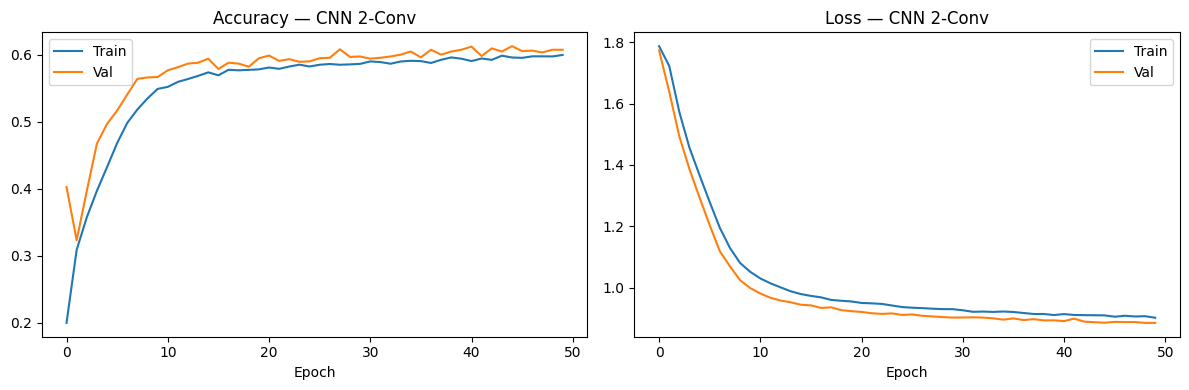

Training curves saved.


In [4]:
# ================================================
# Cell 4 — Training  (AMP + early stopping + save best)
# ================================================
BEST_MODEL_PATH = os.path.join(OUTPUT_DIR, "best_custom_2cnn_model.pth")

# ── AMP setup ──────────────────────────────────────────────────
# GradScaler enables float16 training without gradient underflow.
# AMP is always enabled for custom CNNs (CUDA is required).
scaler_amp        = torch.cuda.amp.GradScaler()

# Track best val_loss; save model whenever it improves
best_val_loss     = float('inf')
epochs_no_improve = 0
train_loss_hist, val_loss_hist = [], []
train_acc_hist,  val_acc_hist  = [], []


# ── Training loop ──────────────────────────────────────────────
# Each epoch: train -> validate -> early stopping -> save best.
# MIN_EPOCHS_BEFORE_STOP=20 prevents premature stopping before
# the loss has stabilised.
for epoch in range(1, EPOCHS + 1):
    # ── Train ──
    model.train()
    run_loss, run_correct, run_total = 0.0, 0, 0

    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [Train]", leave=False):
        inputs, labels = inputs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast():
            outputs = model(inputs)
            loss    = criterion(outputs, labels)

        scaler_amp.scale(loss).backward()
        scaler_amp.step(optimizer)
        scaler_amp.update()

        with torch.no_grad():
            preds = outputs.argmax(1)

        run_loss    += loss.item() * inputs.size(0)
        run_correct += (preds == labels).sum().item()
        run_total   += inputs.size(0)

    train_loss = run_loss / run_total
    train_acc  = run_correct / run_total
    train_loss_hist.append(train_loss)
    train_acc_hist.append(train_acc)

    # ── Validate ──
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch}/{EPOCHS} [Val]", leave=False):
            inputs, labels = inputs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
            with torch.cuda.amp.autocast():
                outputs = model(inputs)
                loss    = criterion(outputs, labels)
            val_loss    += loss.item() * inputs.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total   += inputs.size(0)

    val_loss /= val_total
    val_acc   = val_correct / val_total
    val_loss_hist.append(val_loss)
    val_acc_hist.append(val_acc)

    print(f"[Epoch {epoch:02d}]  "
          f"Train Acc: {train_acc:.4f}  Val Acc: {val_acc:.4f}  "
          f"Train Loss: {train_loss:.4f}  Val Loss: {val_loss:.4f}")

    # ── Early stopping ──
    if val_loss < best_val_loss:
        best_val_loss     = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"  -> Best model saved  (val_loss={best_val_loss:.4f})")
    else:
        epochs_no_improve += 1
        if epoch < MIN_EPOCHS_BEFORE_STOP:
            print(f"  -> No improvement for {epochs_no_improve}/{PATIENCE}, "
                  f"but continuing until at least epoch {MIN_EPOCHS_BEFORE_STOP}.")
        elif epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch} after {epochs_no_improve} epochs without improvement.")
            break

print(f"\nTraining complete. Best model -> {BEST_MODEL_PATH}")


# Plot and save training/validation accuracy and loss per epoch
# ── Learning curves ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_acc_hist, label='Train'); axes[0].plot(val_acc_hist, label='Val')
axes[0].set_title("Accuracy — CNN 2-Conv"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].plot(train_loss_hist, label='Train'); axes[1].plot(val_loss_hist, label='Val')
axes[1].set_title("Loss — CNN 2-Conv"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_curves.png"), dpi=150)
plt.show()
print("Training curves saved.")


     #    True Label    Pred Label   Correct


Inference:   0%|          | 0/94 [00:00<?, ?it/s]

     0             0             0       YES
     1             0             0       YES
     2             0             0       YES
     3             0             0       YES
     4             0             0       YES
     5             0             0       YES
     6             0             0       YES
     7             0             0       YES
     8             0           500       NO 
     9             0             0       YES
    10             0             0       YES
    11             0          1000       NO 
    12             0             0       YES
    13             0             0       YES
    14             0          1500       NO 
    15             0             0       YES
    16             0             0       YES
    17             0             0       YES
    18             0             0       YES
    19             0           500       NO 
    20             0             0       YES
    21             0           500       NO 
    22    

/tmp/ipykernel_19158/2763785418.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


    96             0             0       YES
    97             0             0       YES
    98             0             0       YES
    99             0             0       YES
   100             0           500       NO 
   101             0             0       YES
   102             0             0       YES
   103             0             0       YES
   104             0           500       NO 
   105             0             0       YES
   106             0          1000       NO 
   107             0             0       YES
   108             0             0       YES
   109             0             0       YES
   110             0           500       NO 
   111             0             0       YES
   112             0             0       YES
   113             0             0       YES
   114             0             0       YES
   115             0          1500       NO 
   116             0          1500       NO 
   117             0             0       YES
   118    

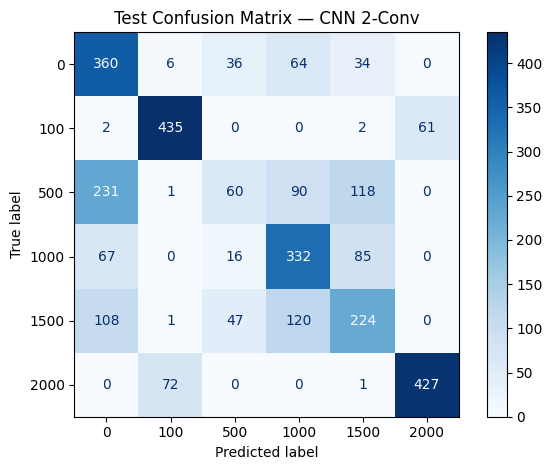


Classification Report — CNN 2-Conv:
              precision    recall  f1-score   support

           0     0.4688    0.7200    0.5678       500
         100     0.8447    0.8700    0.8571       500
         500     0.3774    0.1200    0.1821       500
        1000     0.5479    0.6640    0.6004       500
        1500     0.4828    0.4480    0.4647       500
        2000     0.8750    0.8540    0.8644       500

    accuracy                         0.6127      3000
   macro avg     0.5994    0.6127    0.5894      3000
weighted avg     0.5994    0.6127    0.5894      3000



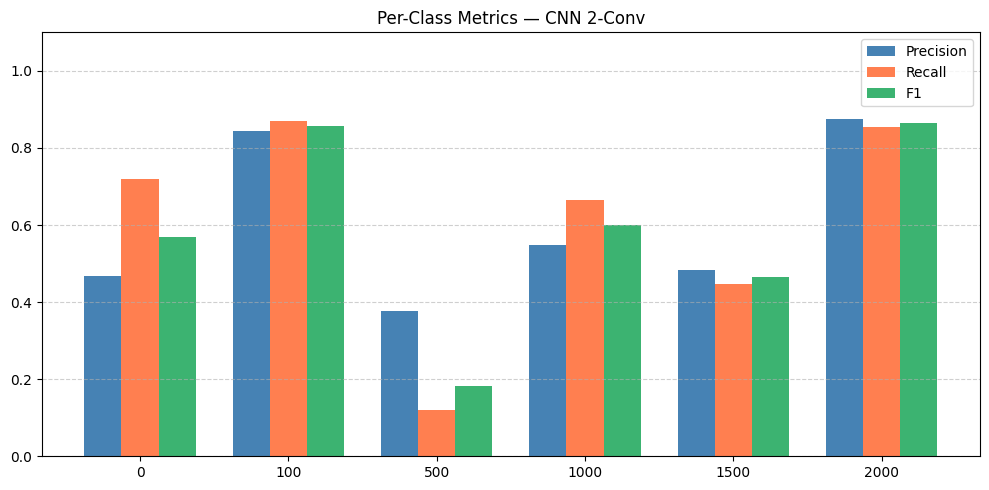

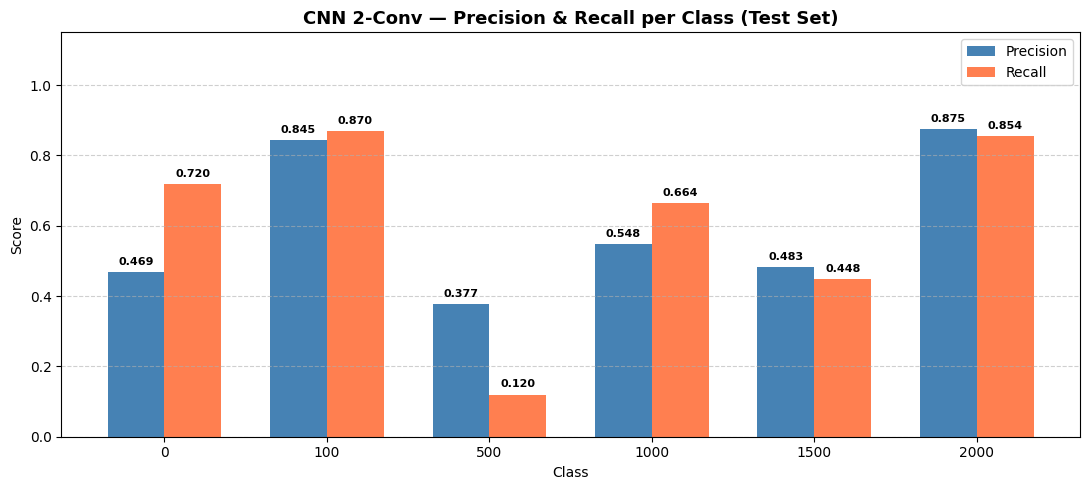

CNN Precision & Recall chart saved.


/tmp/ipykernel_19158/2763785418.py:116: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_19158/2763785418.py:127: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



CNN 2-Conv — Inference Time (100 random samples)
  Average : 0.744 ms / sample
  Std Dev : 0.086 ms
  Min     : 0.570 ms
  Max     : 1.289 ms
CNN inference times saved.


In [5]:
# ================================================
# Cell 5 — CNN Test Evaluation + Inference Print
# ================================================
import time

# ── Load best checkpoint for evaluation ───────────────────────
# Evaluates the best saved weights, not the last epoch weights.
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels, all_probs = [], [], []
sample_idx = 0

print("\n" + "="*65)
print(f"{'#':>6}  {'True Label':>12}  {'Pred Label':>12}  {'Correct':>8}")
print("="*65)

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Inference", leave=False):
        inputs = inputs.to(DEVICE)
        with torch.cuda.amp.autocast():
            outputs = model(inputs)
        probs = F.softmax(outputs, dim=1).cpu().numpy()
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
        all_probs.extend(probs)
        for i in range(len(preds)):
            true_name = CLASS_NAMES[labels[i]]
            pred_name = CLASS_NAMES[preds[i]]
            correct   = "YES" if preds[i] == labels[i].item() else "NO "
            print(f"{sample_idx:>6}  {true_name:>12}  {pred_name:>12}  {correct:>8}")
            sample_idx += 1

print("="*65)

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
test_acc   = (all_preds == all_labels).mean()
print(f"\nTest Accuracy (CNN 2-Conv): {test_acc * 100:.2f}%")
print(f"Correct: {(all_preds == all_labels).sum()} / {len(all_labels)}")


# ── Confusion matrix ───────────────────────────────────────────
# Shows predicted vs true labels across all 6 classes.
# ── Confusion Matrix ──
cm   = confusion_matrix(all_labels, all_preds, labels=list(range(NUM_CLASSES)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(cmap='Blues', values_format='d')
plt.title("Test Confusion Matrix — CNN 2-Conv")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix_cnn.png"), dpi=150)
plt.show()


# ── Full classification report ─────────────────────────────────
# Per-class precision, recall, F1. Saved as .txt and .csv.
# ── Classification Report ──
report_txt = classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=4)
print("\nClassification Report — CNN 2-Conv:")
print(report_txt)
with open(os.path.join(OUTPUT_DIR, "classification_report_cnn.txt"), "w") as f:
    f.write(report_txt)
pd.DataFrame(
    classification_report(all_labels, all_preds, target_names=CLASS_NAMES, output_dict=True, digits=4)
).transpose().to_csv(os.path.join(OUTPUT_DIR, "classification_report_cnn.csv"))


# Per-class metric bar charts (Precision / Recall / F1)
# ── Per-class metrics ──
cnn_precision = precision_score(all_labels, all_preds, average=None, labels=range(NUM_CLASSES))
cnn_recall    = recall_score(all_labels,    all_preds, average=None, labels=range(NUM_CLASSES))
cnn_f1        = f1_score(all_labels,        all_preds, average=None, labels=range(NUM_CLASSES))
x = np.arange(NUM_CLASSES)

# ── Chart 1: Combined Precision / Recall / F1 ──
w = 0.25
plt.figure(figsize=(10, 5))
plt.bar(x - w, cnn_precision, w, label='Precision', color='steelblue')
plt.bar(x,     cnn_recall,    w, label='Recall',    color='coral')
plt.bar(x + w, cnn_f1,        w, label='F1',        color='mediumseagreen')
plt.xticks(x, CLASS_NAMES); plt.ylim(0, 1.1)
plt.title("Per-Class Metrics — CNN 2-Conv")
plt.legend(); plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "per_class_metrics_cnn.png"), dpi=150)
plt.show()

# ── Chart 2: Precision & Recall — grouped on same bar chart ──
w2 = 0.35
plt.figure(figsize=(11, 5))
plt.bar(x - w2/2, cnn_precision, w2, label='Precision', color='steelblue')
plt.bar(x + w2/2, cnn_recall,    w2, label='Recall',    color='coral')
for i in range(NUM_CLASSES):
    plt.text(i - w2/2, cnn_precision[i] + 0.02, f'{cnn_precision[i]:.3f}',
             ha='center', fontsize=8, fontweight='bold')
    plt.text(i + w2/2, cnn_recall[i]    + 0.02, f'{cnn_recall[i]:.3f}',
             ha='center', fontsize=8, fontweight='bold')
plt.xticks(x, CLASS_NAMES); plt.ylim(0, 1.15)
plt.xlabel("Class"); plt.ylabel("Score")
plt.title("CNN 2-Conv — Precision & Recall per Class (Test Set)", fontsize=13, fontweight='bold')
plt.legend(); plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "precision_recall_cnn.png"), dpi=150)
plt.show()
print("CNN Precision & Recall chart saved.")


# Save per-sample true label, predicted label, and correct flag
# ── Raw predictions CSV ──
pd.DataFrame({
    "Sample":     range(len(all_labels)),
    "True Label": [CLASS_NAMES[i] for i in all_labels],
    "Pred Label": [CLASS_NAMES[i] for i in all_preds],
    "Correct":    (all_preds == all_labels).astype(int)
}).to_csv(os.path.join(OUTPUT_DIR, "predictions_cnn.csv"), index=False)

# ================================================
# CNN Inference Time — 100 random test samples
# ================================================
_rng100        = np.random.RandomState(SEED)
_sample_idx    = _rng100.choice(len(test_ds), 100, replace=False)
_timing_loader = DataLoader(Subset(test_ds, _sample_idx), batch_size=1,
                            shuffle=False, num_workers=0)

with torch.no_grad():
    _warm, _ = next(iter(_timing_loader))
    with torch.cuda.amp.autocast():
        _ = model(_warm.to(DEVICE))
torch.cuda.synchronize()

cnn_times_ms = []
model.eval()
with torch.no_grad():
    for _inp, _ in _timing_loader:
        _inp = _inp.to(DEVICE)
        torch.cuda.synchronize()
        _t0 = time.perf_counter()
        with torch.cuda.amp.autocast():
            _ = model(_inp)
        torch.cuda.synchronize()
        cnn_times_ms.append((time.perf_counter() - _t0) * 1000)

cnn_avg_time_ms = float(np.mean(cnn_times_ms))
cnn_std_time_ms = float(np.std(cnn_times_ms))

print("\n" + "="*52)
print("CNN 2-Conv — Inference Time (100 random samples)")
print("="*52)
print(f"  Average : {cnn_avg_time_ms:.3f} ms / sample")
print(f"  Std Dev : {cnn_std_time_ms:.3f} ms")
print(f"  Min     : {np.min(cnn_times_ms):.3f} ms")
print(f"  Max     : {np.max(cnn_times_ms):.3f} ms")
print("="*52)

pd.DataFrame({"sample": range(100), "cnn_time_ms": cnn_times_ms}).to_csv(
    os.path.join(OUTPUT_DIR, "cnn_inference_times.csv"), index=False)
print("CNN inference times saved.")

In [6]:
# ================================================
# Cell 6 — Feature Extraction  (save embeddings)
# ================================================
# ── Feature extraction ─────────────────────────────────────────
# Passes each split through the CNN with return_embedding=True
# to extract 128-d feature vectors from the penultimate layer.
# Embeddings are saved as .npy files for:
#   - mRMR feature selection (Cell 7)
#   - SVM training and evaluation (Cell 8)
#   - PCA visualisation (Cell 9)
def extract_embeddings(loader, model, split_name):
    model.eval()
    embs, ys = [], []
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc=f"Extracting [{split_name}]", leave=False):
            inputs = inputs.to(DEVICE)
            with torch.cuda.amp.autocast():
                _, emb = model(inputs, return_embedding=True)  # (B, 128)
            embs.append(emb.cpu().float().numpy())
            ys.append(labels.numpy())
    return np.concatenate(embs, axis=0), np.concatenate(ys, axis=0)

train_embs, train_y = extract_embeddings(train_loader, model, "train")
val_embs,   val_y   = extract_embeddings(val_loader,   model, "val")
test_embs,  test_y  = extract_embeddings(test_loader,  model, "test")

print(f"Embedding shapes -> train: {train_embs.shape}  val: {val_embs.shape}  test: {test_embs.shape}")

for name, arr in [("train_embs", train_embs), ("val_embs",  val_embs),
                  ("test_embs",  test_embs),  ("train_y",   train_y),
                  ("val_y",      val_y),       ("test_y",    test_y)]:
    np.save(os.path.join(OUTPUT_DIR, f"{name}.npy"), arr)
    print(f"  Saved {name}.npy  shape={arr.shape}")

print("\nAll embeddings saved.")

Extracting [train]:   0%|          | 0/329 [00:00<?, ?it/s]

/tmp/ipykernel_19158/3616339946.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Extracting [val]:   0%|          | 0/47 [00:00<?, ?it/s]

Extracting [test]:   0%|          | 0/94 [00:00<?, ?it/s]

Embedding shapes -> train: (10500, 128)  val: (1500, 128)  test: (3000, 128)
  Saved train_embs.npy  shape=(10500, 128)
  Saved val_embs.npy  shape=(1500, 128)
  Saved test_embs.npy  shape=(3000, 128)
  Saved train_y.npy  shape=(10500,)
  Saved val_y.npy  shape=(1500,)
  Saved test_y.npy  shape=(3000,)

All embeddings saved.


Running mRMR: 12000 samples, 128 features -> selecting K=32 ...


/home/jenarththan/Desktop/FYP/venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/jenarththan/Desktop/FYP/venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



Top 10 selected features (by MI):
 feature_index       mi
           111 0.736232
            68 0.735902
            80 0.735202
           122 0.734956
           107 0.729773
           117 0.726145
            66 0.724884
            96 0.724872
            34 0.723949
            25 0.722340


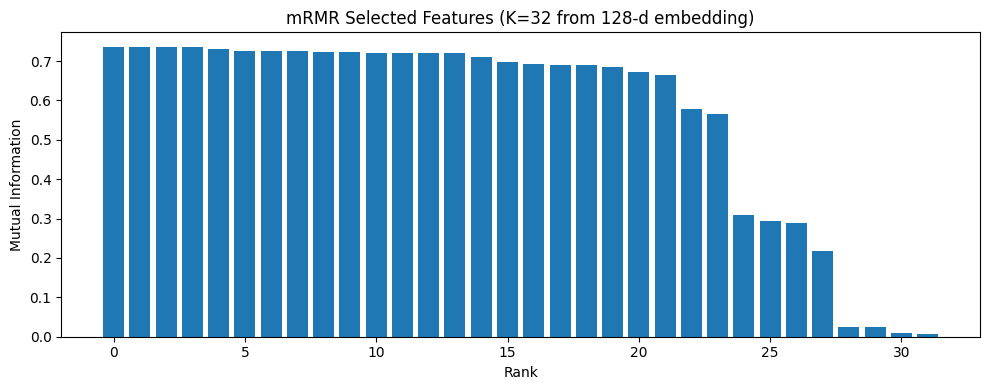

Reduced embedding: 32-d


In [7]:
# ================================================
# Cell 7 — mRMR Feature Selection
# ================================================
# ── mRMR greedy feature selection ──────────────────────────────
# Minimum Redundancy Maximum Relevance (mRMR) selects K features
# that maximise mutual information with the class label while
# minimising redundancy among already-selected features.
#
# Algorithm (greedy):
#   1. Score all features by MI(feature, label)
#   2. Select the highest-MI feature first
#   3. Each subsequent feature maximises: MI(f, label) - mean|corr(f, selected)|
#      (relevance minus redundancy with already-selected set)
#
# K=32 selected from 128-d CNN embeddings.
# Fitted on combined train+val embeddings to maximise coverage.
def mrmr_select(X, y, k, seed=SEED):
    """
    Greedy mRMR:
      relevance  = MI(feature, label)
      redundancy = mean |corr| to already-selected features
      score      = relevance - redundancy
    """
    X, y = np.asarray(X), np.asarray(y)
    k    = min(k, X.shape[1])
    mi   = mutual_info_classif(X, y, random_state=seed, discrete_features=False)
    corr = np.nan_to_num(np.abs(np.corrcoef(X, rowvar=False)), nan=0.0)

    selected  = [int(np.argmax(mi))]
    candidate = set(range(X.shape[1])) - set(selected)

    while len(selected) < k and candidate:
        scores    = {f: mi[f] - np.mean(corr[f, selected]) for f in candidate}
        best_feat = max(scores, key=scores.get)
        selected.append(best_feat)
        candidate.remove(best_feat)

    return selected, mi


# Combine train and val embeddings for mRMR fitting
# (more data -> more reliable MI estimates)
X_tv = np.vstack([train_embs, val_embs])
y_tv = np.hstack([train_y,   val_y])

print(f"Running mRMR: {X_tv.shape[0]} samples, {X_tv.shape[1]} features -> selecting K={K_MRMR} ...")
selected_idx, mi = mrmr_select(X_tv, y_tv, k=K_MRMR)

sel_df = (pd.DataFrame({"feature_index": selected_idx, "mi": mi[selected_idx]})
            .sort_values("mi", ascending=False).reset_index(drop=True))
sel_df.to_csv(os.path.join(OUTPUT_DIR, f"mrmr_selected_{K_MRMR}.csv"), index=False)

print(f"\nTop 10 selected features (by MI):")
print(sel_df.head(10).to_string(index=False))

plt.figure(figsize=(10, 4))
plt.bar(range(len(selected_idx)), sel_df["mi"].values)
plt.xlabel("Rank"); plt.ylabel("Mutual Information")
plt.title(f"mRMR Selected Features (K={K_MRMR} from 128-d embedding)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"mrmr_selected_{K_MRMR}_plot.png"), dpi=150)
plt.show()


# Apply mRMR index selection to reduce 128-d -> 32-d for SVM input
train_sel = train_embs[:, selected_idx]
val_sel   = val_embs[:,   selected_idx]
test_sel  = test_embs[:,  selected_idx]
print(f"Reduced embedding: {train_sel.shape[1]}-d")


     #    True Label    Pred Label   Correct


Inference:   0%|          | 0/94 [00:00<?, ?it/s]

     0             0             0       YES
     1             0             0       YES
     2             0             0       YES
     3             0             0       YES
     4             0             0       YES
     5             0             0       YES
     6             0             0       YES
     7             0             0       YES
     8             0           500       NO 
     9             0             0       YES
    10             0             0       YES
    11             0          1000       NO 
    12             0             0       YES
    13             0             0       YES
    14             0          1500       NO 
    15             0             0       YES
    16             0             0       YES
    17             0             0       YES
    18             0             0       YES
    19             0           500       NO 
    20             0             0       YES
    21             0           500       NO 
    22    

/tmp/ipykernel_19158/2763785418.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


    96             0             0       YES
    97             0             0       YES
    98             0             0       YES
    99             0             0       YES
   100             0           500       NO 
   101             0             0       YES
   102             0             0       YES
   103             0             0       YES
   104             0           500       NO 
   105             0             0       YES
   106             0          1000       NO 
   107             0             0       YES
   108             0             0       YES
   109             0             0       YES
   110             0           500       NO 
   111             0             0       YES
   112             0             0       YES
   113             0             0       YES
   114             0             0       YES
   115             0          1500       NO 
   116             0          1500       NO 
   117             0             0       YES
   118    

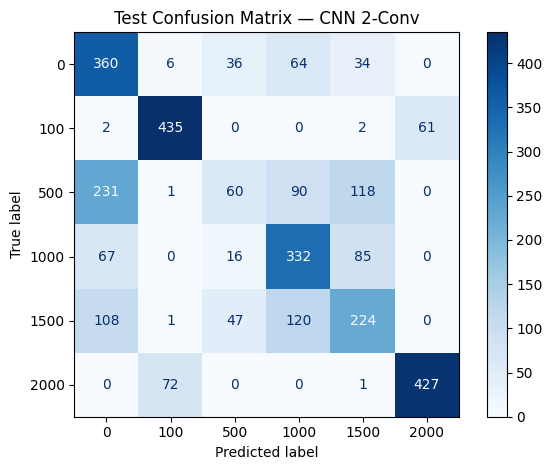


Classification Report — CNN 2-Conv:
              precision    recall  f1-score   support

           0     0.4688    0.7200    0.5678       500
         100     0.8447    0.8700    0.8571       500
         500     0.3774    0.1200    0.1821       500
        1000     0.5479    0.6640    0.6004       500
        1500     0.4828    0.4480    0.4647       500
        2000     0.8750    0.8540    0.8644       500

    accuracy                         0.6127      3000
   macro avg     0.5994    0.6127    0.5894      3000
weighted avg     0.5994    0.6127    0.5894      3000



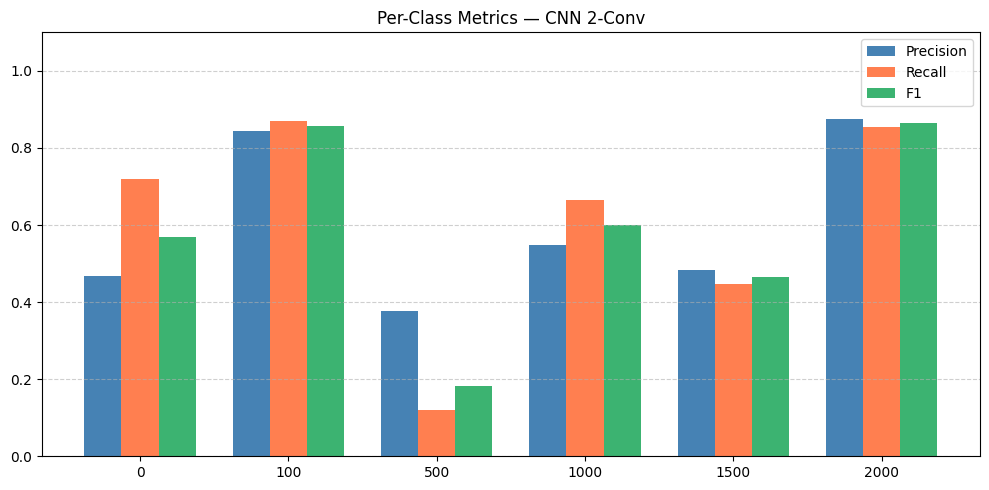

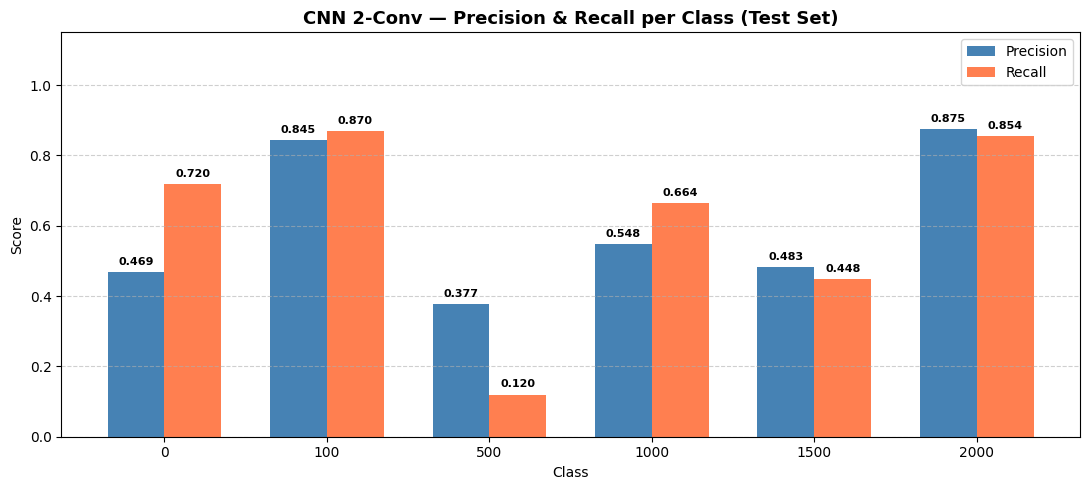

CNN Precision & Recall chart saved.

CNN 2-Conv — Inference Time (100 random samples)
  Average : 0.560 ms / sample
  Std Dev : 0.086 ms
  Min     : 0.425 ms
  Max     : 0.871 ms
CNN inference times saved.


/tmp/ipykernel_19158/2763785418.py:116: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_19158/2763785418.py:127: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


In [8]:
# Duplicate of Cell 5 (CNN evaluation) — re-run block in original notebook

# ================================================
# Cell 5 — CNN Test Evaluation + Inference Print
# ================================================
import time

# ── Load best checkpoint for evaluation ───────────────────────
# Evaluates the best saved weights, not the last epoch weights.
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels, all_probs = [], [], []
sample_idx = 0

print("\n" + "="*65)
print(f"{'#':>6}  {'True Label':>12}  {'Pred Label':>12}  {'Correct':>8}")
print("="*65)

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Inference", leave=False):
        inputs = inputs.to(DEVICE)
        with torch.cuda.amp.autocast():
            outputs = model(inputs)
        probs = F.softmax(outputs, dim=1).cpu().numpy()
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
        all_probs.extend(probs)
        for i in range(len(preds)):
            true_name = CLASS_NAMES[labels[i]]
            pred_name = CLASS_NAMES[preds[i]]
            correct   = "YES" if preds[i] == labels[i].item() else "NO "
            print(f"{sample_idx:>6}  {true_name:>12}  {pred_name:>12}  {correct:>8}")
            sample_idx += 1

print("="*65)

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
test_acc   = (all_preds == all_labels).mean()
print(f"\nTest Accuracy (CNN 2-Conv): {test_acc * 100:.2f}%")
print(f"Correct: {(all_preds == all_labels).sum()} / {len(all_labels)}")


# ── Confusion matrix ───────────────────────────────────────────
# Shows predicted vs true labels across all 6 classes.
# ── Confusion Matrix ──
cm   = confusion_matrix(all_labels, all_preds, labels=list(range(NUM_CLASSES)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(cmap='Blues', values_format='d')
plt.title("Test Confusion Matrix — CNN 2-Conv")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix_cnn.png"), dpi=150)
plt.show()


# ── Full classification report ─────────────────────────────────
# Per-class precision, recall, F1. Saved as .txt and .csv.
# ── Classification Report ──
report_txt = classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=4)
print("\nClassification Report — CNN 2-Conv:")
print(report_txt)
with open(os.path.join(OUTPUT_DIR, "classification_report_cnn.txt"), "w") as f:
    f.write(report_txt)
pd.DataFrame(
    classification_report(all_labels, all_preds, target_names=CLASS_NAMES, output_dict=True, digits=4)
).transpose().to_csv(os.path.join(OUTPUT_DIR, "classification_report_cnn.csv"))


# Per-class metric bar charts (Precision / Recall / F1)
# ── Per-class metrics ──
cnn_precision = precision_score(all_labels, all_preds, average=None, labels=range(NUM_CLASSES))
cnn_recall    = recall_score(all_labels,    all_preds, average=None, labels=range(NUM_CLASSES))
cnn_f1        = f1_score(all_labels,        all_preds, average=None, labels=range(NUM_CLASSES))
x = np.arange(NUM_CLASSES)

# ── Chart 1: Combined Precision / Recall / F1 ──
w = 0.25
plt.figure(figsize=(10, 5))
plt.bar(x - w, cnn_precision, w, label='Precision', color='steelblue')
plt.bar(x,     cnn_recall,    w, label='Recall',    color='coral')
plt.bar(x + w, cnn_f1,        w, label='F1',        color='mediumseagreen')
plt.xticks(x, CLASS_NAMES); plt.ylim(0, 1.1)
plt.title("Per-Class Metrics — CNN 2-Conv")
plt.legend(); plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "per_class_metrics_cnn.png"), dpi=150)
plt.show()

# ── Chart 2: Precision & Recall — grouped on same bar chart ──
w2 = 0.35
plt.figure(figsize=(11, 5))
plt.bar(x - w2/2, cnn_precision, w2, label='Precision', color='steelblue')
plt.bar(x + w2/2, cnn_recall,    w2, label='Recall',    color='coral')
for i in range(NUM_CLASSES):
    plt.text(i - w2/2, cnn_precision[i] + 0.02, f'{cnn_precision[i]:.3f}',
             ha='center', fontsize=8, fontweight='bold')
    plt.text(i + w2/2, cnn_recall[i]    + 0.02, f'{cnn_recall[i]:.3f}',
             ha='center', fontsize=8, fontweight='bold')
plt.xticks(x, CLASS_NAMES); plt.ylim(0, 1.15)
plt.xlabel("Class"); plt.ylabel("Score")
plt.title("CNN 2-Conv — Precision & Recall per Class (Test Set)", fontsize=13, fontweight='bold')
plt.legend(); plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "precision_recall_cnn.png"), dpi=150)
plt.show()
print("CNN Precision & Recall chart saved.")


# Save per-sample true label, predicted label, and correct flag
# ── Raw predictions CSV ──
pd.DataFrame({
    "Sample":     range(len(all_labels)),
    "True Label": [CLASS_NAMES[i] for i in all_labels],
    "Pred Label": [CLASS_NAMES[i] for i in all_preds],
    "Correct":    (all_preds == all_labels).astype(int)
}).to_csv(os.path.join(OUTPUT_DIR, "predictions_cnn.csv"), index=False)

# ================================================
# CNN Inference Time — 100 random test samples
# ================================================
_rng100        = np.random.RandomState(SEED)
_sample_idx    = _rng100.choice(len(test_ds), 100, replace=False)
_timing_loader = DataLoader(Subset(test_ds, _sample_idx), batch_size=1,
                            shuffle=False, num_workers=0)

with torch.no_grad():
    _warm, _ = next(iter(_timing_loader))
    with torch.cuda.amp.autocast():
        _ = model(_warm.to(DEVICE))
torch.cuda.synchronize()

cnn_times_ms = []
model.eval()
with torch.no_grad():
    for _inp, _ in _timing_loader:
        _inp = _inp.to(DEVICE)
        torch.cuda.synchronize()
        _t0 = time.perf_counter()
        with torch.cuda.amp.autocast():
            _ = model(_inp)
        torch.cuda.synchronize()
        cnn_times_ms.append((time.perf_counter() - _t0) * 1000)

cnn_avg_time_ms = float(np.mean(cnn_times_ms))
cnn_std_time_ms = float(np.std(cnn_times_ms))

print("\n" + "="*52)
print("CNN 2-Conv — Inference Time (100 random samples)")
print("="*52)
print(f"  Average : {cnn_avg_time_ms:.3f} ms / sample")
print(f"  Std Dev : {cnn_std_time_ms:.3f} ms")
print(f"  Min     : {np.min(cnn_times_ms):.3f} ms")
print(f"  Max     : {np.max(cnn_times_ms):.3f} ms")
print("="*52)

pd.DataFrame({"sample": range(100), "cnn_time_ms": cnn_times_ms}).to_csv(
    os.path.join(OUTPUT_DIR, "cnn_inference_times.csv"), index=False)
print("CNN inference times saved.")

In [9]:
# Duplicate of Cell 6 (embedding extraction) — re-run block in original notebook

# ================================================
# Cell 6 — Feature Extraction  (save embeddings)
# ================================================
# ── Feature extraction ─────────────────────────────────────────
# Passes each split through the CNN with return_embedding=True
# to extract 128-d feature vectors from the penultimate layer.
# Embeddings are saved as .npy files for:
#   - mRMR feature selection (Cell 7)
#   - SVM training and evaluation (Cell 8)
#   - PCA visualisation (Cell 9)
def extract_embeddings(loader, model, split_name):
    model.eval()
    embs, ys = [], []
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc=f"Extracting [{split_name}]", leave=False):
            inputs = inputs.to(DEVICE)
            with torch.cuda.amp.autocast():
                _, emb = model(inputs, return_embedding=True)  # (B, 128)
            embs.append(emb.cpu().float().numpy())
            ys.append(labels.numpy())
    return np.concatenate(embs, axis=0), np.concatenate(ys, axis=0)

train_embs, train_y = extract_embeddings(train_loader, model, "train")
val_embs,   val_y   = extract_embeddings(val_loader,   model, "val")
test_embs,  test_y  = extract_embeddings(test_loader,  model, "test")

print(f"Embedding shapes -> train: {train_embs.shape}  val: {val_embs.shape}  test: {test_embs.shape}")

for name, arr in [("train_embs", train_embs), ("val_embs",  val_embs),
                  ("test_embs",  test_embs),  ("train_y",   train_y),
                  ("val_y",      val_y),       ("test_y",    test_y)]:
    np.save(os.path.join(OUTPUT_DIR, f"{name}.npy"), arr)
    print(f"  Saved {name}.npy  shape={arr.shape}")

print("\nAll embeddings saved.")

Extracting [train]:   0%|          | 0/329 [00:00<?, ?it/s]

/tmp/ipykernel_19158/3616339946.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Extracting [val]:   0%|          | 0/47 [00:00<?, ?it/s]

Extracting [test]:   0%|          | 0/94 [00:00<?, ?it/s]

Embedding shapes -> train: (10500, 128)  val: (1500, 128)  test: (3000, 128)
  Saved train_embs.npy  shape=(10500, 128)
  Saved val_embs.npy  shape=(1500, 128)
  Saved test_embs.npy  shape=(3000, 128)
  Saved train_y.npy  shape=(10500,)
  Saved val_y.npy  shape=(1500,)
  Saved test_y.npy  shape=(3000,)

All embeddings saved.


Running mRMR: 12000 samples, 128 features -> selecting K=32 ...


/home/jenarththan/Desktop/FYP/venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/jenarththan/Desktop/FYP/venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



Top 10 selected features (by MI):
 feature_index       mi
            80 0.738172
            68 0.734093
           111 0.733093
           122 0.732000
           107 0.730745
           117 0.729960
            96 0.725377
           113 0.723914
            31 0.723828
            25 0.723658


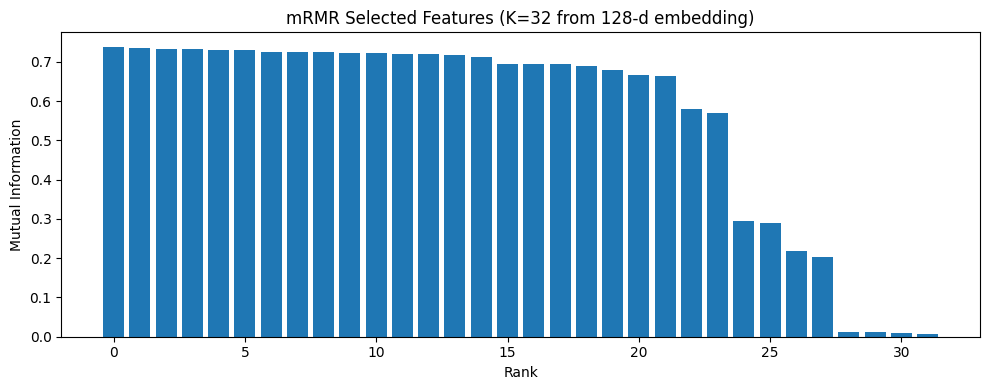

Reduced embedding: 32-d


In [10]:
# Duplicate of Cell 7 (mRMR selection) — re-run block in original notebook

# ================================================
# Cell 7 — mRMR Feature Selection
# ================================================
# ── mRMR greedy feature selection ──────────────────────────────
# Minimum Redundancy Maximum Relevance (mRMR) selects K features
# that maximise mutual information with the class label while
# minimising redundancy among already-selected features.
#
# Algorithm (greedy):
#   1. Score all features by MI(feature, label)
#   2. Select the highest-MI feature first
#   3. Each subsequent feature maximises: MI(f, label) - mean|corr(f, selected)|
#      (relevance minus redundancy with already-selected set)
#
# K=32 selected from 128-d CNN embeddings.
# Fitted on combined train+val embeddings to maximise coverage.
def mrmr_select(X, y, k, seed=SEED):
    """
    Greedy mRMR:
      relevance  = MI(feature, label)
      redundancy = mean |corr| to already-selected features
      score      = relevance - redundancy
    """
    X, y = np.asarray(X), np.asarray(y)
    k    = min(k, X.shape[1])
    mi   = mutual_info_classif(X, y, random_state=seed, discrete_features=False)
    corr = np.nan_to_num(np.abs(np.corrcoef(X, rowvar=False)), nan=0.0)

    selected  = [int(np.argmax(mi))]
    candidate = set(range(X.shape[1])) - set(selected)

    while len(selected) < k and candidate:
        scores    = {f: mi[f] - np.mean(corr[f, selected]) for f in candidate}
        best_feat = max(scores, key=scores.get)
        selected.append(best_feat)
        candidate.remove(best_feat)

    return selected, mi


# Combine train and val embeddings for mRMR fitting
# (more data -> more reliable MI estimates)
X_tv = np.vstack([train_embs, val_embs])
y_tv = np.hstack([train_y,   val_y])

print(f"Running mRMR: {X_tv.shape[0]} samples, {X_tv.shape[1]} features -> selecting K={K_MRMR} ...")
selected_idx, mi = mrmr_select(X_tv, y_tv, k=K_MRMR)

sel_df = (pd.DataFrame({"feature_index": selected_idx, "mi": mi[selected_idx]})
            .sort_values("mi", ascending=False).reset_index(drop=True))
sel_df.to_csv(os.path.join(OUTPUT_DIR, f"mrmr_selected_{K_MRMR}.csv"), index=False)

print(f"\nTop 10 selected features (by MI):")
print(sel_df.head(10).to_string(index=False))

plt.figure(figsize=(10, 4))
plt.bar(range(len(selected_idx)), sel_df["mi"].values)
plt.xlabel("Rank"); plt.ylabel("Mutual Information")
plt.title(f"mRMR Selected Features (K={K_MRMR} from 128-d embedding)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"mrmr_selected_{K_MRMR}_plot.png"), dpi=150)
plt.show()


# Apply mRMR index selection to reduce 128-d -> 32-d for SVM input
train_sel = train_embs[:, selected_idx]
val_sel   = val_embs[:,   selected_idx]
test_sel  = test_embs[:,  selected_idx]
print(f"Reduced embedding: {train_sel.shape[1]}-d")

Training SVM (RBF, C=10) ...
SVM training done.

SVM INFERENCE — per sample
     #    True Label    Pred Label   Correct
     0             0             0       YES
     1             0             0       YES
     2             0             0       YES
     3             0             0       YES
     4             0             0       YES
     5             0             0       YES
     6             0             0       YES
     7             0             0       YES
     8             0           500       NO 
     9             0             0       YES
    10             0             0       YES
    11             0          1000       NO 
    12             0             0       YES
    13             0             0       YES
    14             0          1500       NO 
    15             0             0       YES
    16             0             0       YES
    17             0             0       YES
    18             0             0       YES
    19             0    

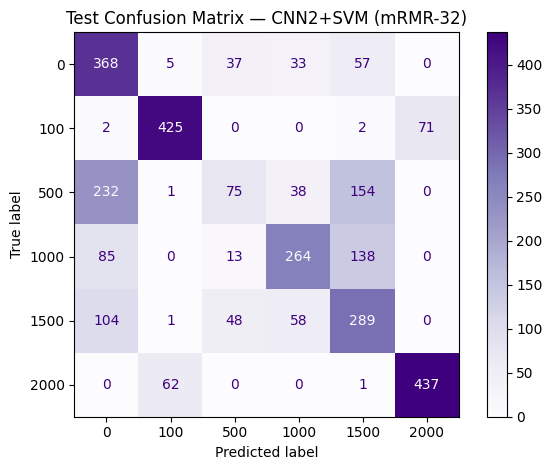


Classification Report — CNN2+SVM (mRMR-32):
              precision    recall  f1-score   support

           0     0.4652    0.7360    0.5701       500
         100     0.8603    0.8500    0.8551       500
         500     0.4335    0.1500    0.2229       500
        1000     0.6718    0.5280    0.5913       500
        1500     0.4509    0.5780    0.5066       500
        2000     0.8602    0.8740    0.8671       500

    accuracy                         0.6193      3000
   macro avg     0.6237    0.6193    0.6022      3000
weighted avg     0.6237    0.6193    0.6022      3000



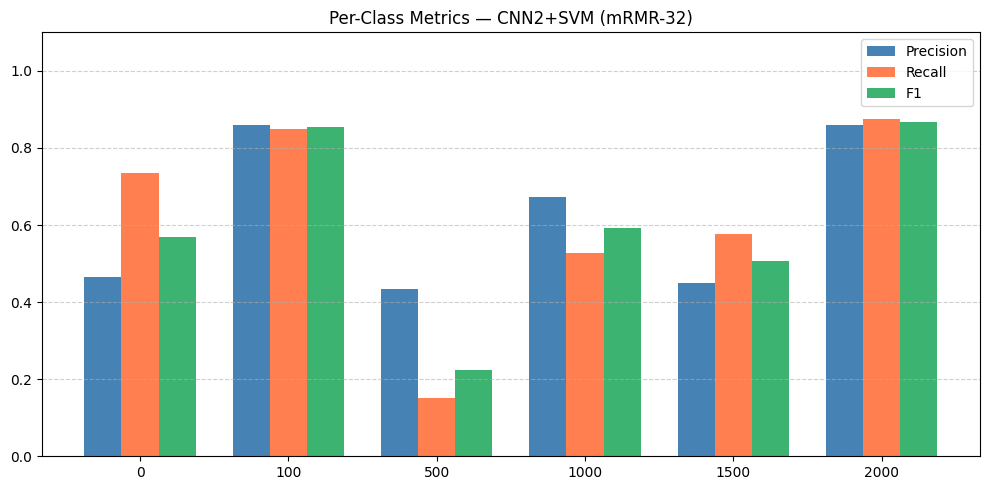

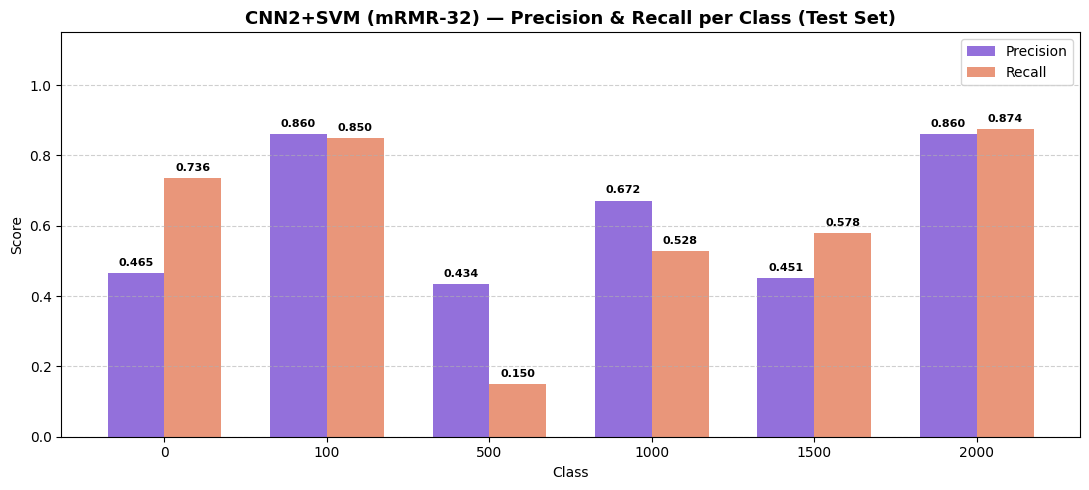

SVM Precision & Recall chart saved.


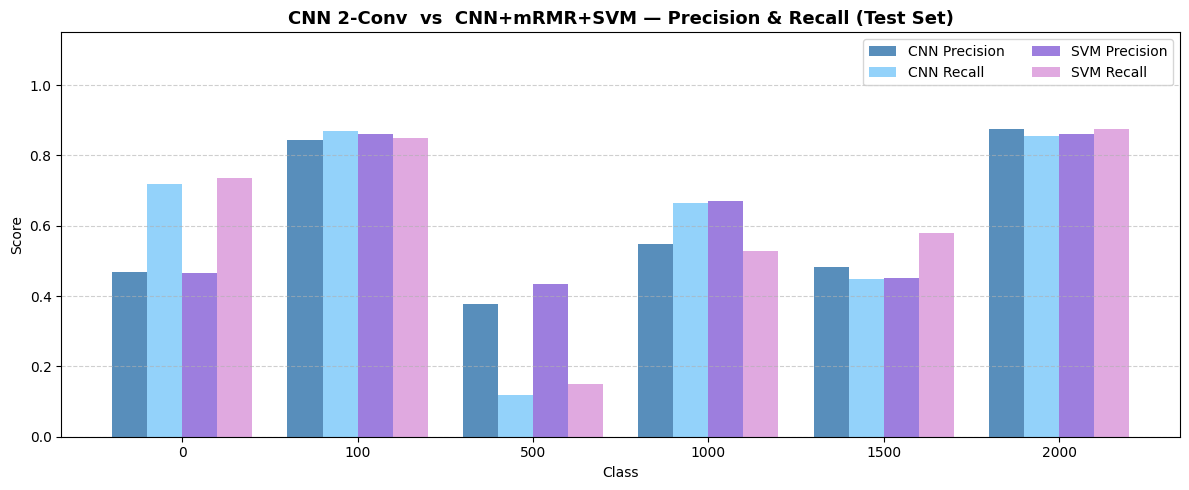

CNN vs SVM comparison chart saved.

SVM (mRMR-32) — Inference Time (100 random samples)
  Average : 0.5193 ms / sample
  Std Dev : 0.0551 ms
  Min     : 0.4516 ms
  Max     : 0.7821 ms

INFERENCE TIME SUMMARY (avg over 100 samples)
  CNN alone        : 0.560 ± 0.086 ms
  SVM alone (mRMR) : 0.5193 ± 0.0551 ms
  Full pipeline    : 1.079 ms  (CNN + SVM)

All artifacts saved in: /home/jenarththan/Desktop/FYP/May11/Notebooks/Custom/CNN2_May11_Results
best_custom_2cnn_model.pth
classification_report_cnn.csv
classification_report_cnn.txt
classification_report_svm_mrmr_32.csv
classification_report_svm_mrmr_32.txt
cnn_inference_times.csv
comparison_cnn_vs_svm_precision_recall.png
confusion_matrix_cnn.png
confusion_matrix_svm_mrmr_32.png
inference_time_summary.csv
mrmr_selected_32.csv
mrmr_selected_32_plot.png
per_class_metrics_cnn.png
per_class_metrics_svm_mrmr_32.png
precision_recall_cnn.png
precision_recall_svm_mrmr_32.png
predictions_cnn.csv
predictions_svm_mrmr_32.csv
scaler_mrmr_svm.joblib

In [11]:
# ================================================
# Cell 8 — SVM Training + Evaluation + Inference
# ================================================
# ── SVM training pipeline ──────────────────────────────────────
# StandardScaler: zero-mean, unit-variance normalisation of the
# 32-d mRMR-selected embeddings. SVMs are sensitive to feature scale;
# normalisation ensures no single dimension dominates the kernel.
# Scaler is fitted on train+val, then applied to test only (no leakage).
scaler       = StandardScaler()
train_std    = scaler.fit_transform(np.vstack([train_sel, val_sel]))
test_std     = scaler.transform(test_sel)
y_train_full = np.hstack([train_y, val_y])

print("Training SVM (RBF, C=10) ...")
svm = SVC(kernel="rbf", C=10.0, gamma="scale", probability=False, random_state=SEED)
svm.fit(train_std, y_train_full)
print("SVM training done.")


# Persist scaler and SVM to disk for future inference without retraining
dump(scaler, os.path.join(OUTPUT_DIR, "scaler_mrmr_svm.joblib"))
dump(svm,    os.path.join(OUTPUT_DIR, "svm_mrmr_rbf.joblib"))


# Run SVM predictions on the full test set
# ── SVM Inference per sample ──
svm_preds = svm.predict(test_std)

print("\n" + "="*65)
print("SVM INFERENCE — per sample")
print(f"{'#':>6}  {'True Label':>12}  {'Pred Label':>12}  {'Correct':>8}")
print("="*65)
for i, (true, pred) in enumerate(zip(test_y, svm_preds)):
    correct = "YES" if true == pred else "NO "
    print(f"{i:>6}  {CLASS_NAMES[true]:>12}  {CLASS_NAMES[pred]:>12}  {correct:>8}")
print("="*65)

svm_acc = (svm_preds == test_y).mean()
print(f"\nTest Accuracy (CNN2 + mRMR-{K_MRMR} + SVM): {svm_acc * 100:.2f}%")
print(f"Correct: {(svm_preds == test_y).sum()} / {len(test_y)}")


# ── Confusion matrix ───────────────────────────────────────────
# Shows predicted vs true labels across all 6 classes.
# ── Confusion Matrix ──
cm_svm = confusion_matrix(test_y, svm_preds, labels=list(range(NUM_CLASSES)))
disp   = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=CLASS_NAMES)
disp.plot(cmap='Purples', values_format='d')
plt.title(f"Test Confusion Matrix — CNN2+SVM (mRMR-{K_MRMR})")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"confusion_matrix_svm_mrmr_{K_MRMR}.png"), dpi=150)
plt.show()


# ── Full classification report ─────────────────────────────────
# Per-class precision, recall, F1. Saved as .txt and .csv.
# ── Classification Report ──
rep_txt = classification_report(test_y, svm_preds, target_names=CLASS_NAMES, digits=4)
print(f"\nClassification Report — CNN2+SVM (mRMR-{K_MRMR}):")
print(rep_txt)
with open(os.path.join(OUTPUT_DIR, f"classification_report_svm_mrmr_{K_MRMR}.txt"), "w") as f:
    f.write(rep_txt)
pd.DataFrame(
    classification_report(test_y, svm_preds, target_names=CLASS_NAMES, output_dict=True, digits=4)
).transpose().to_csv(os.path.join(OUTPUT_DIR, f"classification_report_svm_mrmr_{K_MRMR}.csv"))


# Per-class metric bar charts (Precision / Recall / F1)
# ── Per-class metrics ──
svm_precision = precision_score(test_y, svm_preds, average=None, labels=range(NUM_CLASSES))
svm_recall    = recall_score(test_y,    svm_preds, average=None, labels=range(NUM_CLASSES))
svm_f1        = f1_score(test_y,       svm_preds, average=None, labels=range(NUM_CLASSES))
x = np.arange(NUM_CLASSES)

# ── Chart 1: Combined Precision / Recall / F1 (SVM) ──
w = 0.25
plt.figure(figsize=(10, 5))
plt.bar(x - w, svm_precision, w, label='Precision', color='steelblue')
plt.bar(x,     svm_recall,    w, label='Recall',    color='coral')
plt.bar(x + w, svm_f1,        w, label='F1',        color='mediumseagreen')
plt.xticks(x, CLASS_NAMES); plt.ylim(0, 1.1)
plt.title(f"Per-Class Metrics — CNN2+SVM (mRMR-{K_MRMR})")
plt.legend(); plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"per_class_metrics_svm_mrmr_{K_MRMR}.png"), dpi=150)
plt.show()

# ── Chart 2: Precision & Recall — grouped on same bar chart (SVM) ──
w2 = 0.35
plt.figure(figsize=(11, 5))
plt.bar(x - w2/2, svm_precision, w2, label='Precision', color='mediumpurple')
plt.bar(x + w2/2, svm_recall,    w2, label='Recall',    color='darksalmon')
for i in range(NUM_CLASSES):
    plt.text(i - w2/2, svm_precision[i] + 0.02, f'{svm_precision[i]:.3f}',
             ha='center', fontsize=8, fontweight='bold')
    plt.text(i + w2/2, svm_recall[i]    + 0.02, f'{svm_recall[i]:.3f}',
             ha='center', fontsize=8, fontweight='bold')
plt.xticks(x, CLASS_NAMES); plt.ylim(0, 1.15)
plt.xlabel("Class"); plt.ylabel("Score")
plt.title(f"CNN2+SVM (mRMR-{K_MRMR}) — Precision & Recall per Class (Test Set)",
          fontsize=13, fontweight='bold')
plt.legend(); plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"precision_recall_svm_mrmr_{K_MRMR}.png"), dpi=150)
plt.show()
print("SVM Precision & Recall chart saved.")


# ── CNN vs SVM comparison chart ────────────────────────────────
# Side-by-side precision and recall bars for CNN-only vs CNN+SVM.
# Shows whether mRMR + SVM improves over the direct CNN classifier.
# ── Chart 3: CNN vs SVM comparison (Precision & Recall same chart) ──
w3 = 0.2
plt.figure(figsize=(12, 5))
plt.bar(x - 1.5*w3, cnn_precision, w3, label='CNN Precision',     color='steelblue',    alpha=0.9)
plt.bar(x - 0.5*w3, cnn_recall,    w3, label='CNN Recall',        color='lightskyblue', alpha=0.9)
plt.bar(x + 0.5*w3, svm_precision, w3, label='SVM Precision',     color='mediumpurple', alpha=0.9)
plt.bar(x + 1.5*w3, svm_recall,    w3, label='SVM Recall',        color='plum',         alpha=0.9)
plt.xticks(x, CLASS_NAMES); plt.ylim(0, 1.15)
plt.xlabel("Class"); plt.ylabel("Score")
plt.title("CNN 2-Conv  vs  CNN+mRMR+SVM — Precision & Recall (Test Set)",
          fontsize=13, fontweight='bold')
plt.legend(ncol=2); plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "comparison_cnn_vs_svm_precision_recall.png"), dpi=150)
plt.show()
print("CNN vs SVM comparison chart saved.")

# ── Predictions CSV ──
pd.DataFrame({
    "Sample":     range(len(test_y)),
    "True Label": [CLASS_NAMES[i] for i in test_y],
    "Pred Label": [CLASS_NAMES[i] for i in svm_preds],
    "Correct":    (svm_preds == test_y).astype(int)
}).to_csv(os.path.join(OUTPUT_DIR, f"predictions_svm_mrmr_{K_MRMR}.csv"), index=False)

# ================================================
# SVM Inference Time — same 100 random test samples
# ================================================
_rng100     = np.random.RandomState(SEED)
_sample_idx = _rng100.choice(len(test_y), 100, replace=False)
_test_100   = test_std[_sample_idx]

_ = svm.predict(_test_100[:1])   # warm-up

svm_times_ms = []
for i in range(100):
    _t0 = time.perf_counter()
    _   = svm.predict(_test_100[i : i + 1])
    svm_times_ms.append((time.perf_counter() - _t0) * 1000)

svm_avg_time_ms = float(np.mean(svm_times_ms))
svm_std_time_ms = float(np.std(svm_times_ms))

print("\n" + "="*55)
print(f"SVM (mRMR-{K_MRMR}) — Inference Time (100 random samples)")
print("="*55)
print(f"  Average : {svm_avg_time_ms:.4f} ms / sample")
print(f"  Std Dev : {svm_std_time_ms:.4f} ms")
print(f"  Min     : {np.min(svm_times_ms):.4f} ms")
print(f"  Max     : {np.max(svm_times_ms):.4f} ms")
print("="*55)

pd.DataFrame({"sample": range(100), "svm_time_ms": svm_times_ms}).to_csv(
    os.path.join(OUTPUT_DIR, f"svm_inference_times_{K_MRMR}.csv"), index=False)


# Print inference time breakdown: CNN alone vs SVM alone vs full pipeline
# ── Final Summary ──
pipeline_avg = cnn_avg_time_ms + svm_avg_time_ms
print("\n" + "="*55)
print("INFERENCE TIME SUMMARY (avg over 100 samples)")
print("="*55)
print(f"  CNN alone        : {cnn_avg_time_ms:.3f} ± {cnn_std_time_ms:.3f} ms")
print(f"  SVM alone (mRMR) : {svm_avg_time_ms:.4f} ± {svm_std_time_ms:.4f} ms")
print(f"  Full pipeline    : {pipeline_avg:.3f} ms  (CNN + SVM)")
print("="*55)

pd.DataFrame({
    "Stage":   ["CNN only", f"SVM mRMR-{K_MRMR}", "Full Pipeline"],
    "Avg_ms":  [round(cnn_avg_time_ms, 4), round(svm_avg_time_ms, 4), round(pipeline_avg, 4)],
    "Std_ms":  [round(cnn_std_time_ms, 4), round(svm_std_time_ms, 4), "-"],
}).to_csv(os.path.join(OUTPUT_DIR, "inference_time_summary.csv"), index=False)

print("\n" + "="*50)
print("All artifacts saved in:", OUTPUT_DIR)
print("="*50)
print(os.linesep.join(sorted(os.listdir(OUTPUT_DIR))))

Embeddings : (3000, 128)
True labels: (3000,)
Classes    : ['0', '100', '500', '1000', '1500', '2000']
PCA output : /home/jenarththan/Desktop/FYP/May11/Notebooks/Custom/CNN2_May11_Results/PCA_Analysis

Explained variance: PC1=0.869  PC2=0.097  Total=0.967


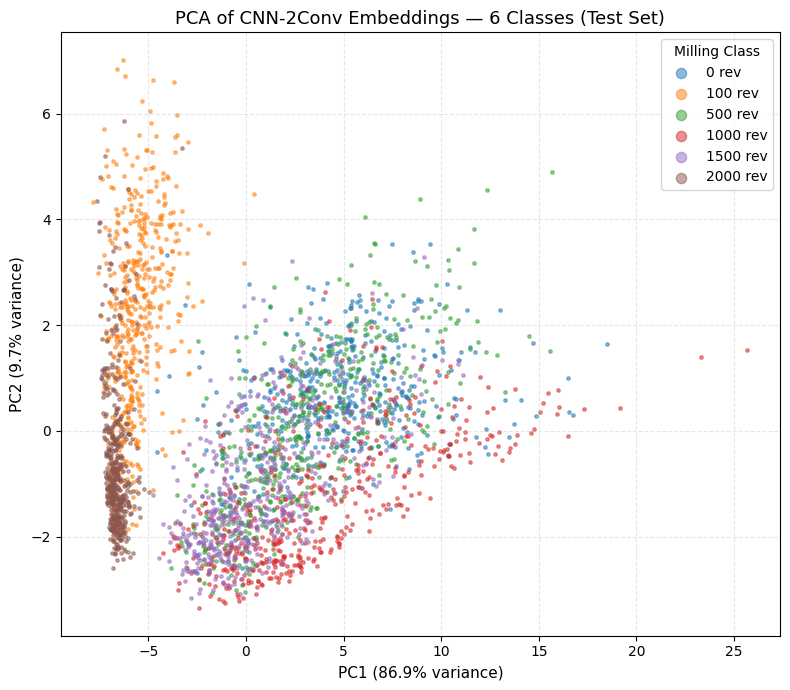

Saved: pca_embeddings.png


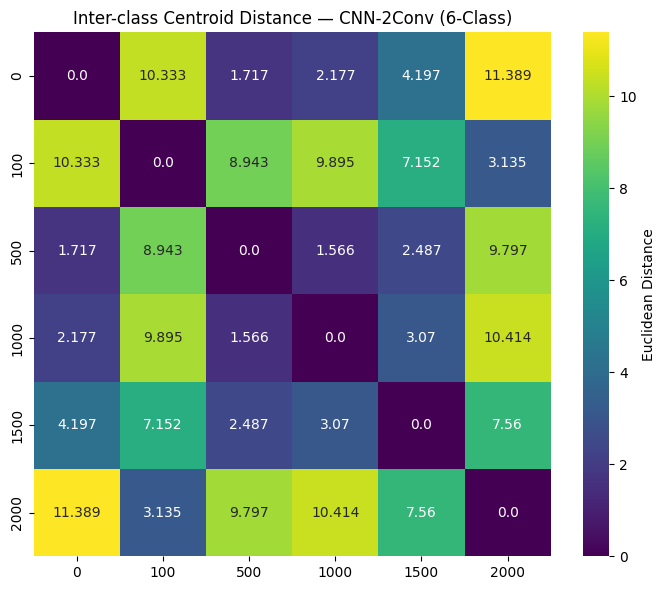

Saved: distance_heatmap.png


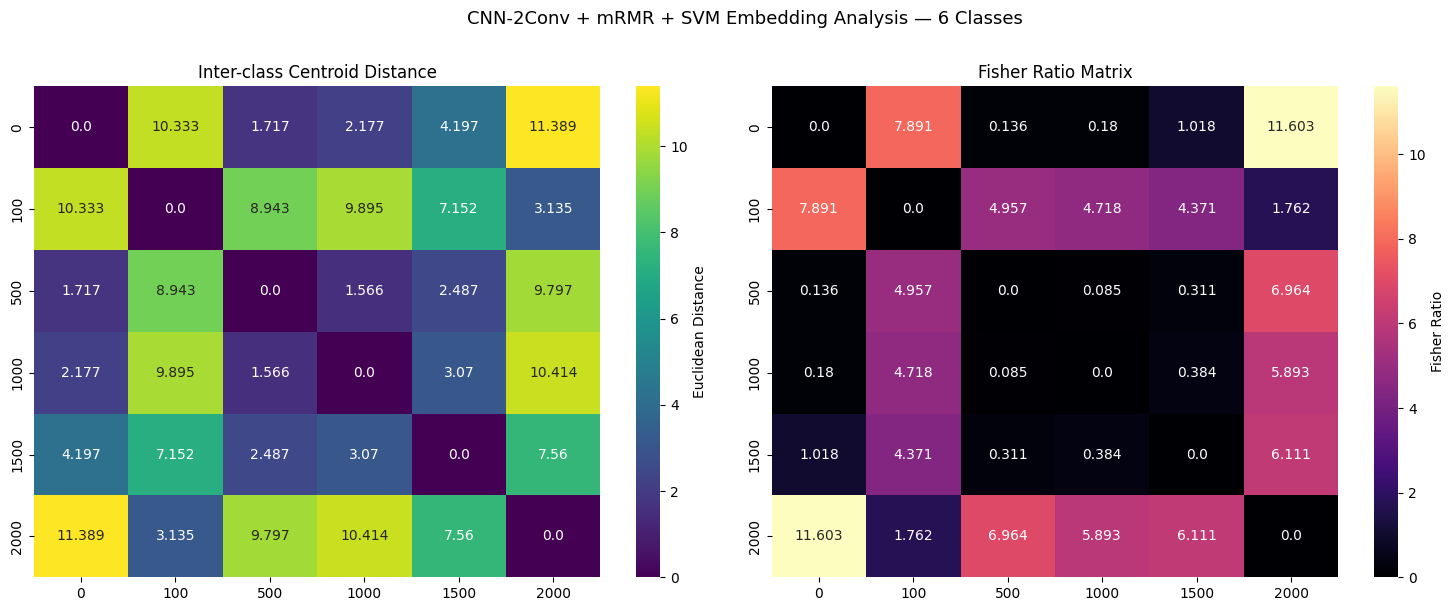

Saved: distance_fisher_side_by_side.png


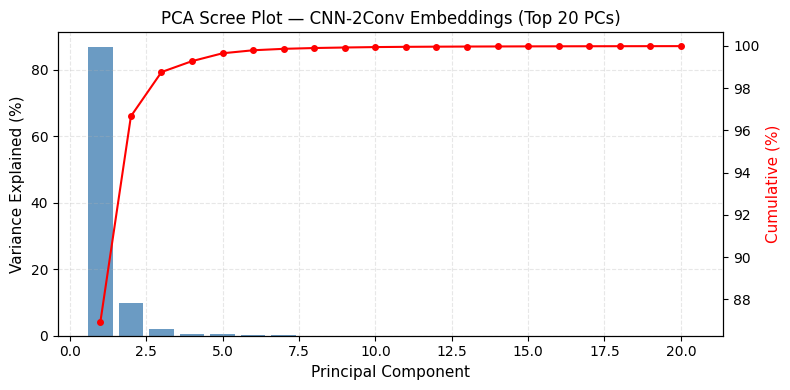

Saved: pca_scree_plot.png

All PCA results saved to: /home/jenarththan/Desktop/FYP/May11/Notebooks/Custom/CNN2_May11_Results/PCA_Analysis
PC1+PC2 explains : 96.7%
PCs for 95% var  : 2


In [12]:
# ================================================
# Cell 9 — PCA Analysis of CNN Embeddings
# ================================================
# ── PCA analysis libraries ─────────────────────────────────────
# seaborn: heatmaps | scipy: centroid distances | sklearn PCA
import seaborn as sns
from scipy.spatial.distance import cdist
from sklearn.decomposition import PCA
from glob import glob

PCA_DIR = os.path.join(OUTPUT_DIR, "PCA_Analysis")
os.makedirs(PCA_DIR, exist_ok=True)


# ── Load CNN embeddings ────────────────────────────────────────
# PCA is performed on the raw 128-d CNN embeddings (not mRMR-reduced)
# to visualise the full representational quality of the CNN features.
# Load CNN embeddings saved by Cell 6
test_embs = np.load(os.path.join(OUTPUT_DIR, "test_embs.npy"))
y_true    = np.load(os.path.join(OUTPUT_DIR, "test_y.npy"))

# Find predictions CSV (SVM predictions saved by Cell 8)
pred_csvs = glob(os.path.join(OUTPUT_DIR, "predictions_*.csv"))
assert pred_csvs, f"No predictions CSV found in {OUTPUT_DIR}. Run Cell 8 first."
pred_df      = pd.read_csv(pred_csvs[0])
label_to_idx = {name: i for i, name in enumerate(CLASS_NAMES)}
y_pred = np.array([label_to_idx[str(l)] for l in pred_df["Pred Label"].values])

COLORS = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b'][:NUM_CLASSES]

print(f"Embeddings : {test_embs.shape}")
print(f"True labels: {y_true.shape}")
print(f"Classes    : {CLASS_NAMES}")
print(f"PCA output : {PCA_DIR}")


# ── PCA 2-D projection ─────────────────────────────────────────
# Projects 128-d embeddings onto 2 PCs. Overlapping clusters here
# explain the lower CNN accuracy — shallow features are less
# discriminative than deeper pretrained architectures.
# ── PCA 2D scatter ──────────────────────────────
pca = PCA(n_components=2, random_state=42)
Z   = pca.fit_transform(test_embs)
var = pca.explained_variance_ratio_
print(f"\nExplained variance: PC1={var[0]:.3f}  PC2={var[1]:.3f}  Total={var.sum():.3f}")

fig, ax = plt.subplots(figsize=(8, 7))
for i, name in enumerate(CLASS_NAMES):
    idx = (y_true == i)
    ax.scatter(Z[idx, 0], Z[idx, 1], s=6, alpha=0.5, label=f'{name} rev', color=COLORS[i])
ax.set_title(f'PCA of CNN-2Conv Embeddings — {NUM_CLASSES} Classes (Test Set)', fontsize=13)
ax.set_xlabel(f'PC1 ({var[0]*100:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({var[1]*100:.1f}% variance)', fontsize=11)
ax.legend(markerscale=3, fontsize=10, title='Milling Class')
ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(os.path.join(PCA_DIR, "pca_embeddings.png"), dpi=300)
plt.show()
print("Saved: pca_embeddings.png")


# Inter-class centroid distances in 128-d embedding space
# ── Centroid distances ──────────────────────────
centroids, intra_spread = [], []
for i in range(NUM_CLASSES):
    Xc = test_embs[y_true == i]
    mu = Xc.mean(axis=0)
    centroids.append(mu)
    intra_spread.append(np.mean(np.linalg.norm(Xc - mu, axis=1)))
centroids    = np.vstack(centroids)
intra_spread = np.array(intra_spread)

inter   = cdist(centroids, centroids, metric='euclidean')
dist_df = pd.DataFrame(inter, index=CLASS_NAMES, columns=CLASS_NAMES)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(dist_df.round(3), annot=True, fmt='', cmap='viridis', ax=ax,
            cbar_kws={'label': 'Euclidean Distance'})
ax.set_title(f'Inter-class Centroid Distance — CNN-2Conv ({NUM_CLASSES}-Class)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(PCA_DIR, "distance_heatmap.png"), dpi=300)
plt.show()
print("Saved: distance_heatmap.png")


# Fisher ratio and combined heatmaps for the paper figure
# ── Fisher ratio + side-by-side ─────────────────
intra_var = intra_spread ** 2
F = np.zeros((NUM_CLASSES, NUM_CLASSES))
for a in range(NUM_CLASSES):
    for b in range(NUM_CLASSES):
        if a != b:
            F[a, b] = (inter[a, b] ** 2) / (intra_var[a] + intra_var[b] + 1e-8)
fish_df = pd.DataFrame(F, index=CLASS_NAMES, columns=CLASS_NAMES)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(dist_df.round(3), annot=True, fmt='', cmap='viridis', ax=axes[0],
            cbar_kws={'label': 'Euclidean Distance'})
axes[0].set_title('Inter-class Centroid Distance', fontsize=12)
sns.heatmap(fish_df.round(3), annot=True, fmt='', cmap='magma', ax=axes[1],
            cbar_kws={'label': 'Fisher Ratio'})
axes[1].set_title('Fisher Ratio Matrix', fontsize=12)
fig.suptitle(f'CNN-2Conv + mRMR + SVM Embedding Analysis — {NUM_CLASSES} Classes', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(PCA_DIR, "distance_fisher_side_by_side.png"), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: distance_fisher_side_by_side.png")


# PCA scree plot: variance explained per component (bar)
# and cumulative variance (red line) for first 20 PCs
# ── Scree plot ──────────────────────────────────
pca_full = PCA(random_state=42).fit(test_embs)
cum_var  = np.cumsum(pca_full.explained_variance_ratio_)
fig, ax  = plt.subplots(figsize=(8, 4))
ax.bar(range(1, 21), pca_full.explained_variance_ratio_[:20]*100, color='steelblue', alpha=0.8)
ax2 = ax.twinx()
ax2.plot(range(1, 21), cum_var[:20]*100, color='red', marker='o', ms=4)
ax.set_xlabel('Principal Component', fontsize=11)
ax.set_ylabel('Variance Explained (%)', fontsize=11)
ax2.set_ylabel('Cumulative (%)', fontsize=11, color='red')
ax.set_title('PCA Scree Plot — CNN-2Conv Embeddings (Top 20 PCs)', fontsize=12)
ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(os.path.join(PCA_DIR, "pca_scree_plot.png"), dpi=150)
plt.show()
print("Saved: pca_scree_plot.png")


# Export distance matrix, Fisher matrix, spread summary, and
# 2D PCA coordinates to CSV for reproducibility
# ── Save CSVs ───────────────────────────────────
dist_df.to_csv(os.path.join(PCA_DIR, "pairwise_centroid_distance.csv"))
fish_df.to_csv(os.path.join(PCA_DIR, "pairwise_fisher_ratio.csv"))
pd.DataFrame({'Class': CLASS_NAMES, 'Intra_spread': intra_spread.round(4),
              'N_samples': [int(np.sum(y_true == i)) for i in range(NUM_CLASSES)]
}).to_csv(os.path.join(PCA_DIR, "class_spread_summary.csv"), index=False)
pd.DataFrame({'PC1': Z[:,0], 'PC2': Z[:,1],
              'True_Label': [CLASS_NAMES[i] for i in y_true]
}).to_csv(os.path.join(PCA_DIR, "pca_coordinates.csv"), index=False)

n_95 = int(np.searchsorted(cum_var, 0.95)) + 1
print(f"\nAll PCA results saved to: {PCA_DIR}")
print(f"PC1+PC2 explains : {cum_var[1]*100:.1f}%")
print(f"PCs for 95% var  : {n_95}")